## load model

In [15]:
import joblib
model = joblib.load("../models/final_pipeline.pkl")

## import libraries

In [16]:
from sklearn.model_selection import train_test_split
import shap

In [17]:
import os
import sys
sys.path.append(os.path.abspath(".."))

In [18]:
from src.Data_preprocessing import preprocess
from src.Feature_Engineering import feature_Engineering
from src.best_preprocessor import  get_best_preprocessor
df=preprocess()
df= feature_Engineering(df)

## train test split

- to get x_test and y_test

In [19]:
x=df.drop("charges",axis=1)
y=df["charges"]
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)


## get y_pred

In [20]:
y_pred = model.predict(X_test)

## Visualization

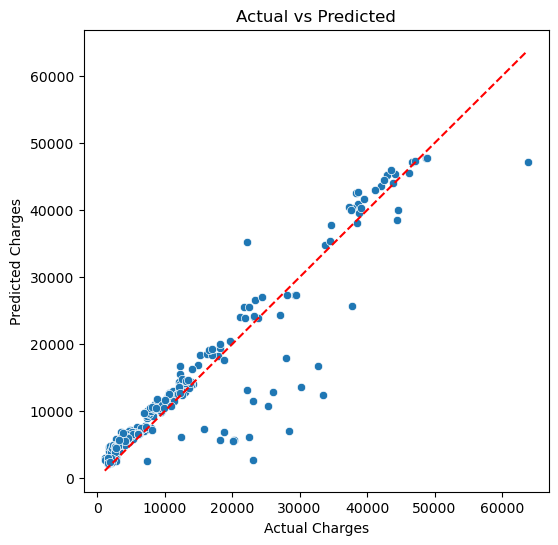

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")

plt.savefig("../Figures/Actual vs Predicted.png")
plt.show()

-  some pred < actual -->under prediction 

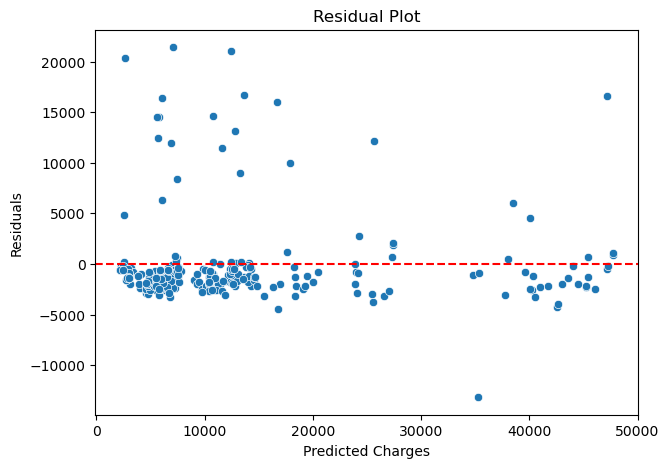

In [22]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)
#draw horizontal line at 0 
# residual can be neg or pos

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.savefig("../Figures/Residual Plot.png")
plt.show()

- residuals = y_test - y_pred
- if residual negative 
- y_pred > y_test
- predicted > actual

- but here error around zero not large problem

- but large error pos above zero -->large problem , large error
-  y_test > y_pred
- Actual > predicted
- Under-predicting

- The model tends to underpredict high-charge observations, as indicated by the large positive residuals. It also shows some overprediction, but the positive residuals are more pronounced.

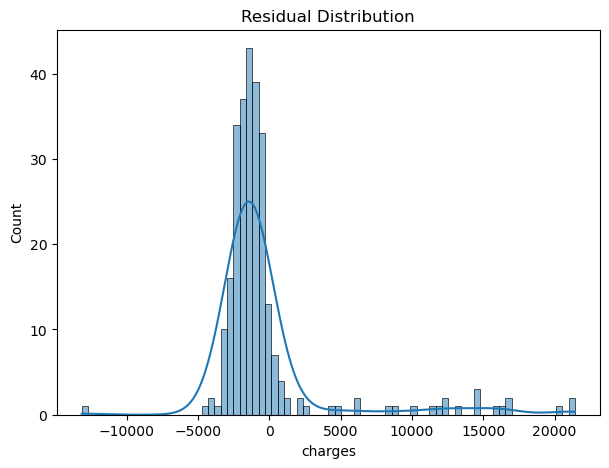

In [23]:
plt.figure(figsize=(7,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.savefig("../Figures/Residual Distribution.png")
plt.show()

## Feature Importance

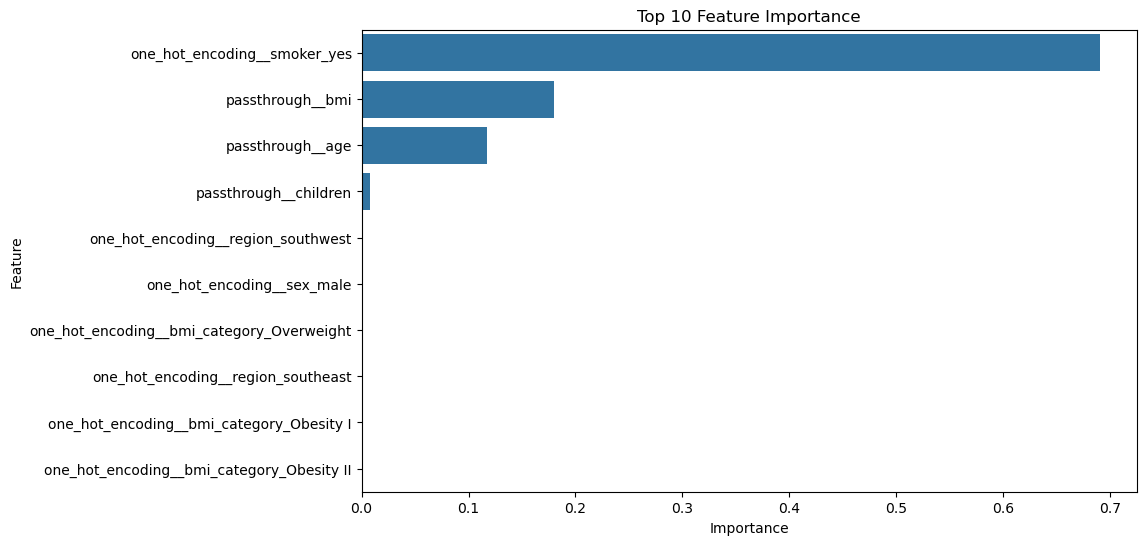

In [24]:
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()
importance = model.named_steps[
    "model"
].feature_importances_


import pandas as pd
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(
    by="Importance",
    ascending=False
)


plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Feature Importance")
plt.show()

## SHAP

In [25]:
preprocessor = model.named_steps["preprocessor"]

model = model.named_steps["model"]

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()



explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_processed)

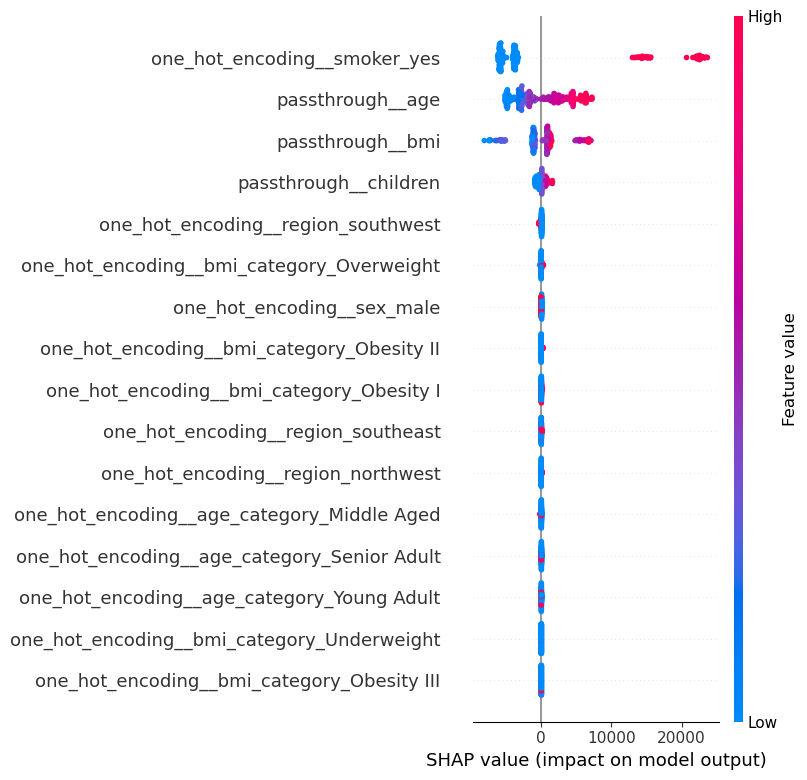

In [26]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

- **The SHAP summary plot shows that smoking status is the most influential feature in predicting insurance charges, followed by age and BMI. High values of age and BMI generally increase the predicted charges, while smoking has the strongest positive effect on the model's output. In contrast, features such as region, sex, children, and BMI categories contribute only slightly to the final predictions, indicating that they have a relatively low impact on the model's decisions.**

- **This SHAP summary plot shows that smoker_yes, age, and bmi have the greatest impact on the model’s predictions; points on the right increase the prediction, points on the left decrease it, while red represents high feature values and blue represents low feature values.**

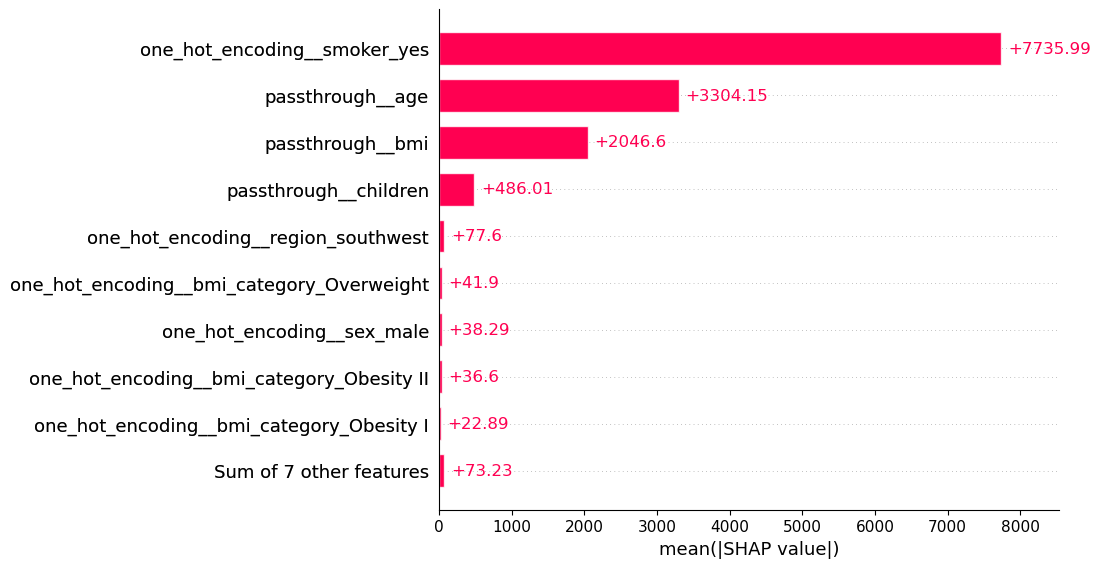

In [27]:
X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)
explainer = shap.Explainer(model)
shap_values = explainer(X_test_processed_df)

shap.plots.bar(shap_values)

- **This SHAP bar plot shows that smoker_yes is the most important feature with an average absolute SHAP impact of about 7730, followed by age (3304) and bmi (2048), meaning the model relies mostly on smoking status, age, and BMI when making its predictions.**

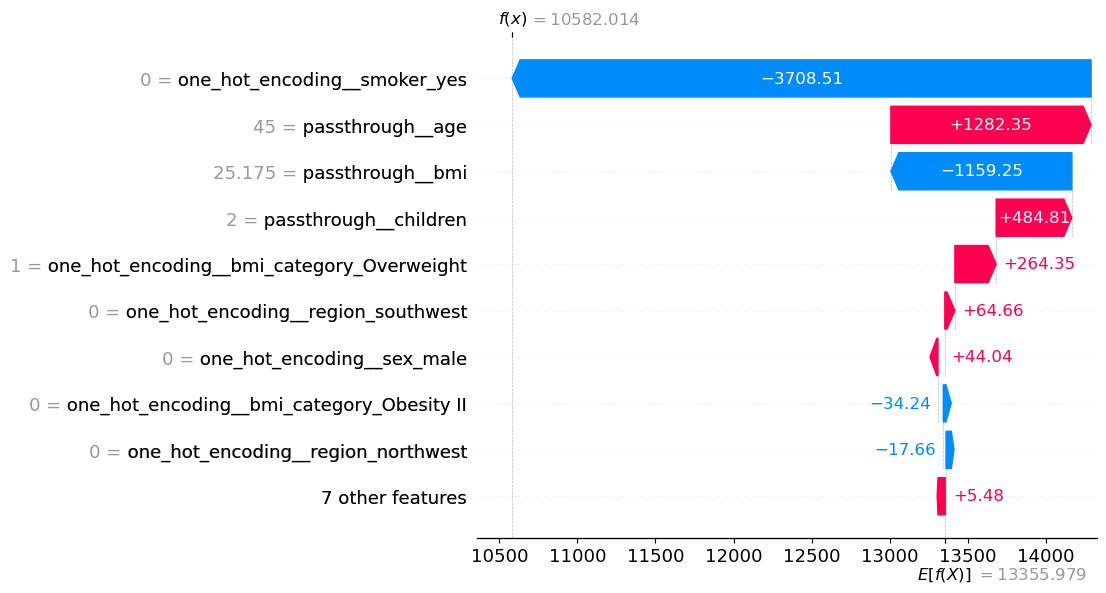

In [28]:
shap.plots.waterfall(shap_values[0])

- **This waterfall plot explains one y_pred (the prediction for this specific sample): it starts from the base value E[f(X)] = 13345.595, then each feature pushes the prediction up or down—smoker_yes decreases it by 3670.69, age increases it by 1298.98, BMI decreases it by 1110.5, and the other features make smaller changes—until it reaches the final prediction y_pred = f(x) = 10655.987.**

- **The base value is the average prediction of the model on the reference/background data, and SHAP uses it as the starting point for explaining an individual prediction.**